# Tugas Kelompok Capstone (CC26-PSU096)

Tema Kelompok: (Accessible & Adaptive Learning)  
Nama/Judul Kelompok: (Coding Camp Copilot)

Daftar Anggota:
- Devi Listiani Safitri (CDCC226D6X1183) - Data Scientist
- Anthony Saputra (CDCC429D6Y0092) - Data Scientist
- Rizki Alsyareno (CFCC848D6Y0433) - Full-Stack Web Developer
- Siti Nur Padila (CFCC809D6X0843) - Full-Stack Web Developer
- Naila Hilwatus Syifa (CACC284D6X1586) - AI Engineer
- Gabriella Elizabeth Devabharata (CACC284D6X1746) - AI Engineer

## Menentukan Permasalahan Dalam Projek, dan Menentukan Solusi utama Yang di Kembangkan

### permasalahan
- 
- 
### solusi
- 
- 


## Pertanyaan Bisnis Yang Dapat Di Ukur

- Kategori jalur mana (ai engineer, data sains, full stack development) yang memiliki volume pertanyaan terbanyak dalam dataset, dan berapa persentase dominasinya?
- Apa 10 kata kunci atau topik yang paling sering muncul dalam pertanyaan peserta secara keseluruhan, dan apakah topik tersebut berbeda antar kategori jalur?


## kumpulan Library yang di gunakan


In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import matplotlib.ticker as mticker
import seaborn as sns
import re
from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

## Data Wrangling

### Gathering Data

In [2]:
df = pd.read_csv("./data/Dataset_Capstone_Project.csv")

### Assessing Data

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID          177 non-null    object
 1   Nama        363 non-null    object
 2   Path        260 non-null    object
 3   Pertanyaan  364 non-null    object
 4   Jawaban     354 non-null    object
dtypes: object(5)
memory usage: 14.4+ KB


In [4]:
df.describe()

,ID,Nama,Path,Pertanyaan,Jawaban
count,177,363,260,364,354
unique,139,312,15,363,314
top,CDCC284D6X2016,Indra S.,ai_engineer,"Halo kak, mau nanya buat 'menambahkan detail a...",silahkan menghubungi pihak coding camp team un...
freq,5,4,67,2,13


In [5]:
df.isnull().sum()

ID            188
Nama            2
Path          105
Pertanyaan      1
Jawaban        11
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["Pertanyaan"].unique()
df["Jawaban"].value_counts()

Jawaban
silahkan menghubungi pihak coding camp team untuk mendapatkan pengecekan lebih lanjut                                                                                                                                                                                                                                                                                                                                 13
silahkan menghubungi pihak coding camp team untuk mendapatkan pengecekan lebih lanjut\r                                                                                                                                                                                                                                                                                                                                6
silahkan menghubungi coding camp team                                                                                                                                         

In [8]:
df["Pertanyaan"].str.len().describe()
df["Jawaban"].str.len().describe()

count    354.000000
mean     165.310734
std      158.284338
min        1.000000
25%       64.000000
50%      106.000000
75%      210.750000
max      981.000000
Name: Jawaban, dtype: float64

In [9]:
(df["Jawaban"] == "").sum()

np.int64(0)

In [10]:
df["Pertanyaan"].str.strip().value_counts()

Pertanyaan
Halo kak, mau nanya buat 'menambahkan detail aktivitas lain'  maksudnya di bagian 'List of Action Items' kah jadi tambah baris baru buat aktivitas lainnya?                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                2
Ijin bertanya kak, terkait dengan daily check-in. Ini kan dilakukan setiap hari kerja dan dalam pengisian daily tersebut juga ada pengisian materi apa saja yang sudah diselesaikan. Nah misal sudah menyelesaikan semua materi tetapi waktu masih berjalan dengan daily check-in, apakah dalam daily check-in t

In [11]:
df["Jawaban"].str.contains(r"[^a-zA-Z0-9\s]", regex=True).sum()

252

In [12]:


data_dict = {
    "Nama Kolom": [
        "ID",
        "Nama",
        "Path",
        "Pertanyaan",
        "Jawaban"
    ],
    "Tipe Data": [
        "string (object)",
        "string (object)",
        "string (object / kategorikal)",
        "string (object / teks bebas)",
        "string (object / teks bebas)"
    ],
    "Deskripsi": [
        "Identitas unik peserta CodingCamp yang mengajukan pertanyaan.",
        "Nama atau username peserta yang mengajukan pertanyaan di forum/chat CodingCamp.",
        "Jalur/bidang studi peserta. Berisi 3 kategori utama: Data Sains, AI Engineer, Full Stack Development. Kolom ini diubah nama menjadi 'Kategori' setelah proses cleaning.",
        "Teks pertanyaan yang diajukan peserta mengenai program Capstone CodingCamp. Merupakan fitur utama (input) untuk model AI.",
        "Teks jawaban atas pertanyaan peserta, diberikan oleh mentor/admin CodingCamp. Merupakan target (output) untuk model AI."
    ],
    "Jumlah Null": [
        "188 (51.5%)",
        "2 (0.5%)",
        "105 (28.8%)",
        "1 (0.3%)",
        "11 (3.0%)"
    ],
    "Nilai Unik": [
        "139 ID",
        "312 nama",
        "15 variasi raw → 3 kategori bersih",
        "363 dari 364 baris",
        "314 dari 354 baris"
    ],
    "Contoh Nilai": [
        "CACC319D6Y0511, CFCC316D6Y1322",
        "Andre, Siddiq_Febri, Jovan",
        "ai_engineer, data_Sains, full_stack development",
        "'Izin bertanya, apakah laporan teknis...'",
        "'Berbeda ya, tapi mungkin saling beririsan'"
    ],
    "Penanganan saat Cleaning": [
        "Kolom dihapus (drop) karena tidak relevan untuk analisis.",
        "Null diisi dengan nilai 'Na'.",
        "Nama kolom diganti menjadi 'Kategori'. Teks dinormalisasi (lowercase, hapus underscore). Inkonsistensi penulisan (ai angineer, data scientist, dll) diperbaiki ke nilai standar. Null diisi 'Na'.",
        "Teks di-lowercase, URL dihapus, karakter non-alfanumerik dihapus. Baris dengan panjang < 15 karakter dihapus.",
        "Null diisi teks default. Teks di-lowercase, URL dihapus, karakter non-alfanumerik dihapus. Baris dengan panjang < 15 karakter dihapus."
    ]
}

df_dict = pd.DataFrame(data_dict)

print("=" * 80)
print("DATA DICTIONARY — Dataset_Capstone_Project.csv")
print("=" * 80)
print(f"Jumlah baris  : 365")
print(f"Jumlah kolom  : 5")
print(f"Sumber data   : Forum/chat program CodingCamp")
print(f"Bahasa data   : Indonesia (informal/conversational)")
print("=" * 80)

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

print(df_dict.to_string(index=False))

DATA DICTIONARY — Dataset_Capstone_Project.csv
Jumlah baris  : 365
Jumlah kolom  : 5
Sumber data   : Forum/chat program CodingCamp
Bahasa data   : Indonesia (informal/conversational)
Nama Kolom                     Tipe Data                                                                                                                                                               Deskripsi Jumlah Null                         Nilai Unik                                    Contoh Nilai                                                                                                                                                                          Penanganan saat Cleaning
        ID               string (object)                                                                                                           Identitas unik peserta CodingCamp yang mengajukan pertanyaan. 188 (51.5%)                             139 ID                  CACC319D6Y0511, CFCC316D6Y1322                

### Kesimpulan Assessing Data

- Dataset terdiri dari 365 baris dengan 5 kolom bertipe string.
- Ditemukan missing values yang cukup banyak pada kolom ID sebanyak 188 dan Path sebanyaak 105.
- Tidak ditemukan data duplikat pada dataset.
- Kolom Pertanyaan memiliki nilai yang hampir seluruhnya unik, menunjukkan variasi input yang tinggi.
- Kolom Jawaban memiliki beberapa nilai yang sering muncul, mengindikasikan adanya respon template.
- Panjang teks pada kolom Jawaban cukup bervariasi, dengan beberapa nilai sangat panjang.
- Ditemukan karakter bukan huruf yang kemungkinan berasal dari tanda baca.

### Cleaning Data

In [13]:
df["Jawaban"] = df["Jawaban"].fillna("maaf, jawaban tidak di temukan silahkan hubungin pihak dicodingcamp")

In [14]:
df = df.rename(columns={"Path": "Kategori"})
df["Kategori"] = df["Kategori"].str.lower().str.strip()
df["Kategori"] = df["Kategori"].str.replace("_", " ")

In [15]:
df = df.drop(columns=["ID"])

In [16]:
df["Kategori"].value_counts()

Kategori
data sains                89
ai engineer               67
full stack developmen     57
full stack development    29
data scientist             8
ai angineer                7
ai enginner                1
ai enginee                 1
full stack                 1
Name: count, dtype: int64

In [17]:
df["Kategori"] = df["Kategori"].replace({
    "ai angineer": "ai engineer",
    "ai enginner": "ai engineer",
    "ai enginee": "ai engineer",
    
    "full stack developmen": "full stack development",
    "full stack": "full stack development",
    
    "data scientist": "data sains"
})

In [18]:
df["Kategori"].value_counts()

Kategori
data sains                97
full stack development    87
ai engineer               76
Name: count, dtype: int64

In [19]:
df.isnull().sum()

Nama            2
Kategori      105
Pertanyaan      1
Jawaban         0
dtype: int64

In [20]:
df["Kategori"] = df["Kategori"].fillna("Na")
df["Nama"] = df["Nama"].fillna("Na")
df.isnull().sum()

Nama          0
Kategori      0
Pertanyaan    1
Jawaban       0
dtype: int64

In [21]:
def clean_text(text):
    text = str(text).lower().strip()
    text = re.sub(r"http\S+", "", text) 
    return re.sub(r"[^a-zA-Z0-9\s]", "", text)

df["Pertanyaan"] = df["Pertanyaan"].apply(clean_text)
df["Jawaban"] = df["Jawaban"].apply(clean_text)
df.head()

,Nama,Kategori,Pertanyaan,Jawaban
0,Siddiq_Febri,data sains,permisi kak saya mau nanya apakah boleh menggunakan email credentials kita d...,gak disarankan sih kak soalnya saat program ini selesai akun nya bakal di re...
1,Andre,full stack development,halo semua izin bertanya apakah laporan teknis yang merupakan bagian dari te...,berbeda ya tapi mungkin saling beririsan
2,Jovan,ai engineer,izin bertanya kalau sudah mendaftarkan tim itu dapet validasi email bahwa ti...,jika sudah mendaftar tim capstone tim capstone akan mendapatkan email valida...
3,Alfito,ai engineer,linimasa yang seperti ini si dimana ya,untuk linimasa reporting kampus bisa mengacu pada deck technical briefing ya
4,Andre,full stack development,apakah ppt dari capstone briefing kemarin ada dibagi kak atau terdapat dokum...,dokumen playbook capstone \nchecklist tech stack \ndokumen faq capstone


In [22]:
jumlah_sebelum = df.shape[0]
df = df[df["Pertanyaan"].str.len() > 15]
df = df[df["Jawaban"].str.len() > 15]
jumlah_sesudah = df.shape[0]

terhapus = jumlah_sebelum - jumlah_sesudah

print("Sebelum:", jumlah_sebelum)
print("Sesudah:", jumlah_sesudah)
print("Data terhapus:", terhapus)


Sebelum: 365
Sesudah: 355
Data terhapus: 10


In [23]:
persen = (terhapus / jumlah_sebelum) * 100
print(f"Persentase data terhapus: {persen:.2f}%")

Persentase data terhapus: 2.74%


In [24]:
df["Pertanyaan"].str.len().describe()
df["Jawaban"].str.len().describe()

count    355.000000
mean     161.529577
std      152.972215
min       16.000000
25%       66.000000
50%      104.000000
75%      196.000000
max      960.000000
Name: Jawaban, dtype: float64

In [25]:
def normalisasi_kategori(nilai):
    if pd.isna(nilai):
        return 'Tidak Diketahui'
    
    nilai = str(nilai).strip().lower()

    # AI Engineer
    if nilai in ['ai engineer', 'ai enginner', 'ai enginee']:
        return 'AI Engineer'

    # Data Sains
    elif nilai in ['data sains', 'data scientist']:
        return 'Data Sains'

    # Full Stack
    elif nilai in ['full stack development', 'full stack developmen', 'full stack']:
        return 'Full Stack Development'

    else:
        return 'Tidak Diketahui'

df['Kategori_Bersih'] = df['Kategori'].apply(normalisasi_kategori)
df['Kategori_Bersih'].value_counts()

Kategori_Bersih
Tidak Diketahui           101
Data Sains                 93
Full Stack Development     86
AI Engineer                75
Name: count, dtype: int64

In [26]:
df.to_csv("./data/data_bersih.csv", index=False)

### kesimpulan cleaning data
- Mengisi nilai kosong pada kolom Jawaban dengan respon default untuk menjaga konsistensi data.
- Mengubah kolom Path menjadi Kategori karena berisi informasi bidang, kemudian dilakukan normalisasi teks serta perbaikan inkonsistensi penulisan.
- Menghapus kolom ID karena tidak relevan pada analisis.
- Melakukan preprocessing teks pada kolom Pertanyaan dan Jawaban dengan mengubah huruf menjadi lowercase, menghapus spasi berlebih, menghapus URL, serta karakter bukan huruf.
- Menangani missing values pada kolom lain seperti Nama dan Kategori.
- Dilakukan filtering berdasarkan panjang teks, namun tidak terdapat data yang dihapus karena seluruh data telah memenuhi kriteria panjang minimal.


## feature engineering

In [27]:
df_feature = df.copy()

In [28]:
df_feature["Panjang_Pertanyaan"] = df_feature["Pertanyaan"].str.len()
df_feature["Panjang_Jawaban"] = df_feature["Jawaban"].str.len()

df_feature["Jumlah_Kata_Pertanyaan"] = df_feature["Pertanyaan"].str.split().apply(len)
df_feature["Jumlah_Kata_Jawaban"] = df_feature["Jawaban"].str.split().apply(len)

df_feature["Kategori_Label"] = df_feature["Kategori_Bersih"].astype("category").cat.codes

# simpan hasil cleaning + feature manual
df_feature.to_csv("./data/data_bersih.csv", index=False)

In [29]:
#Stopword Removal
factory = StopWordRemoverFactory()
stopwords = factory.get_stop_words()
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stopwords]
    return " ".join(filtered_words)
df_feature["Pertanyaan_Bersih"] = df_feature["Pertanyaan"].apply(remove_stopwords)

In [30]:
#Stemming
factory_stem = StemmerFactory()
stemmer = factory_stem.create_stemmer()

def stemming(text):
    return stemmer.stem(text)

df_feature["Pertanyaan_Bersih"] = (
    df_feature["Pertanyaan_Bersih"]
    .apply(stemming)
)

In [31]:
# stopword
factory = StopWordRemoverFactory()
stopwords = factory.get_stop_words()

def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stopwords]
    return " ".join(filtered_words)

# stemming
factory_stem = StemmerFactory()
stemmer = factory_stem.create_stemmer()

def stemming(text):
    return stemmer.stem(text)

# preprocessing
df_feature["Pertanyaan_Bersih"] = (
    df_feature["Pertanyaan"]
    .apply(remove_stopwords)
    .apply(stemming)
)

In [32]:
df_feature[["Pertanyaan", "Pertanyaan_Bersih"]].head()

,Pertanyaan,Pertanyaan_Bersih
0,permisi kak saya mau nanya apakah boleh menggunakan email credentials kita d...,permisi kak mau nanya guna email credentials transaksi subscriptio misal lan...
1,halo semua izin bertanya apakah laporan teknis yang merupakan bagian dari te...,halo semua izin tanya lapor teknis rupa bagi tech stack data science sama pr...
2,izin bertanya kalau sudah mendaftarkan tim itu dapet validasi email bahwa ti...,izin tanya kalau daftar tim dapet validasi email tim udah daftar kapan masa ...
3,linimasa yang seperti ini si dimana ya,linimasa si
4,apakah ppt dari capstone briefing kemarin ada dibagi kak atau terdapat dokum...,ppt capstone briefing kemarin bagi kak dapat dokumen khusus jelas lebih rinc...


In [33]:
print(df_feature["Kategori_Bersih"].value_counts())

Kategori_Bersih
Tidak Diketahui           101
Data Sains                 93
Full Stack Development     86
AI Engineer                75
Name: count, dtype: int64


## EDA

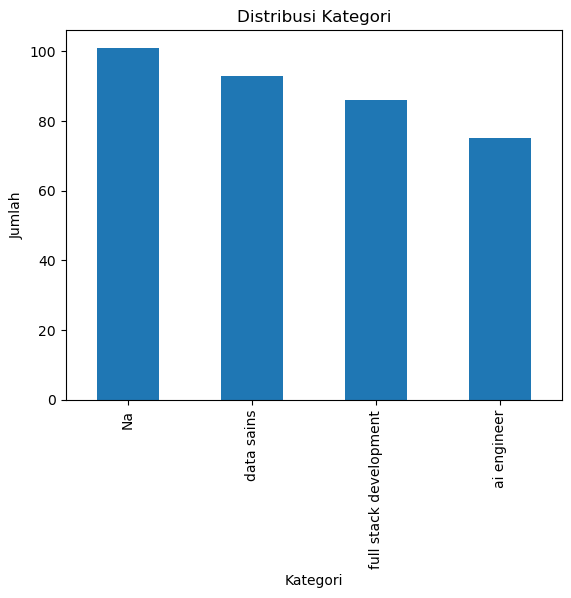

In [34]:
df["Kategori"].value_counts().plot(kind="bar")
plt.title("Distribusi Kategori")
plt.xlabel("Kategori")
plt.ylabel("Jumlah")
plt.show()

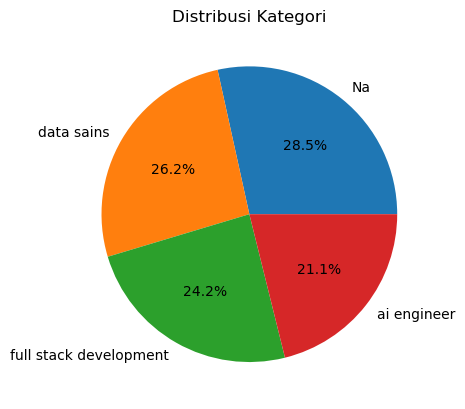

In [35]:
df["Kategori"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",   
)

plt.title("Distribusi Kategori")
plt.ylabel("")  
plt.show()

In [36]:
df["Pertanyaan_len"] = df["Pertanyaan"].str.len()
df["Jawaban_len"] = df["Jawaban"].str.len()
df[["Pertanyaan_len", "Jawaban_len"]].describe()

,Pertanyaan_len,Jawaban_len
count,355.000000,355.000000
mean,203.569014,161.529577
std,144.659205,152.972215
min,22.000000,16.000000
25%,99.500000,66.000000
50%,165.000000,104.000000
75%,260.500000,196.000000
max,885.000000,960.000000


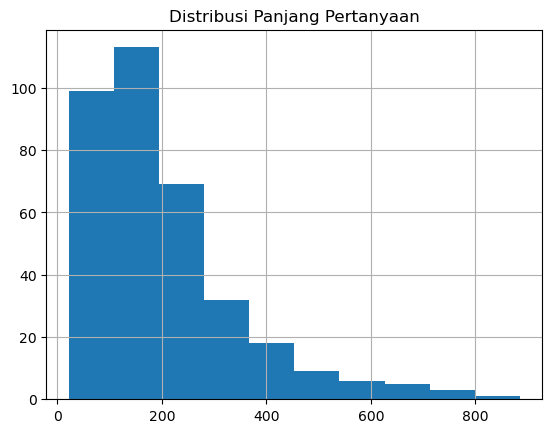

In [37]:
df["Pertanyaan_len"].hist()
plt.title("Distribusi Panjang Pertanyaan")
plt.show()

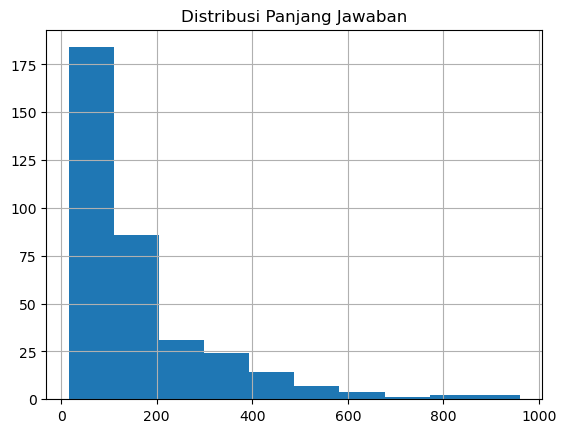

In [38]:
df["Jawaban_len"].hist()
plt.title("Distribusi Panjang Jawaban")
plt.show()

In [39]:
df.groupby("Kategori")["Jawaban_len"].mean()

Kategori
Na                        185.524752
ai engineer               153.626667
data sains                165.462366
full stack development    135.988372
Name: Jawaban_len, dtype: float64

In [40]:

all_text = " ".join(df["Pertanyaan"])
words = all_text.split()

Counter(words).most_common(10)

[('saya', 365),
 ('apakah', 228),
 ('yang', 204),
 ('di', 188),
 ('kak', 184),
 ('dan', 175),
 ('untuk', 155),
 ('tidak', 147),
 ('ada', 128),
 ('sudah', 126)]

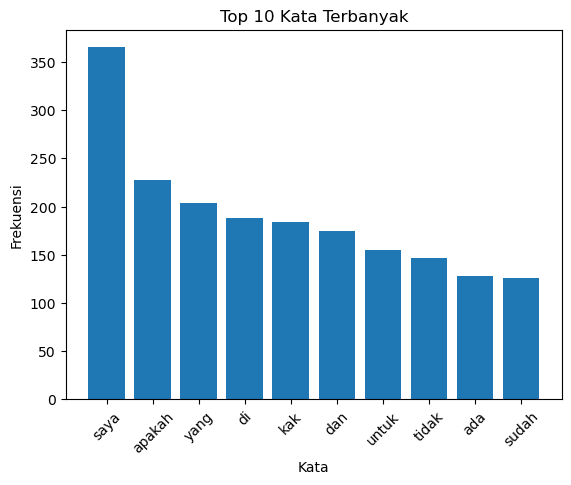

In [41]:


all_text = " ".join(df["Pertanyaan"])
words = all_text.split()

word_counts = Counter(words).most_common(10)

# pisahkan kata & jumlah
kata = [w[0] for w in word_counts]
jumlah = [w[1] for w in word_counts]

plt.figure()
plt.bar(kata, jumlah)
plt.title("Top 10 Kata Terbanyak")
plt.xlabel("Kata")
plt.ylabel("Frekuensi")
plt.xticks(rotation=45)
plt.show()

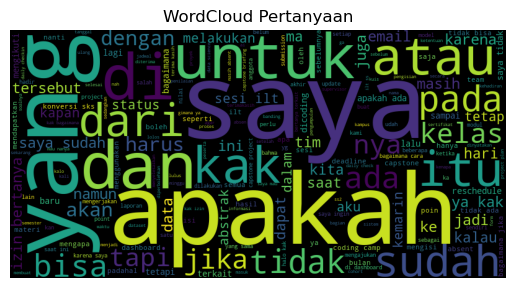

In [42]:


text = " ".join(df["Pertanyaan"])

wc = WordCloud(width=800, height=400).generate(text)

plt.figure()
plt.imshow(wc)
plt.axis("off")
plt.title("WordCloud Pertanyaan")
plt.show()

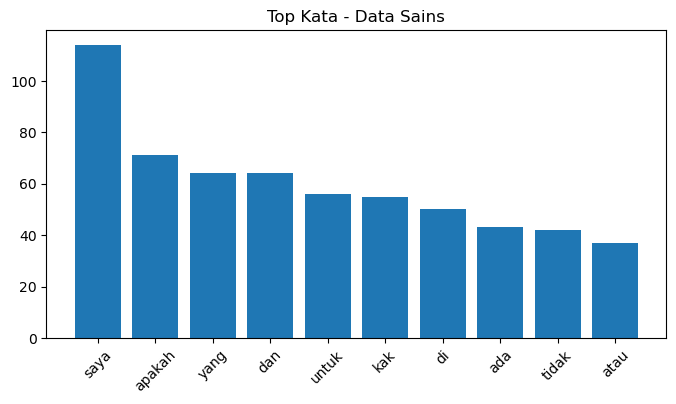

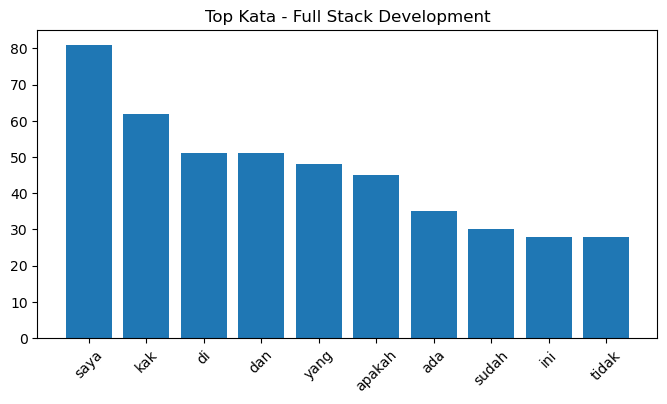

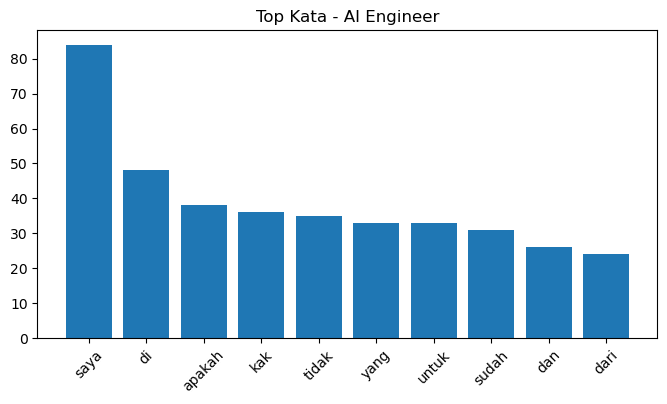

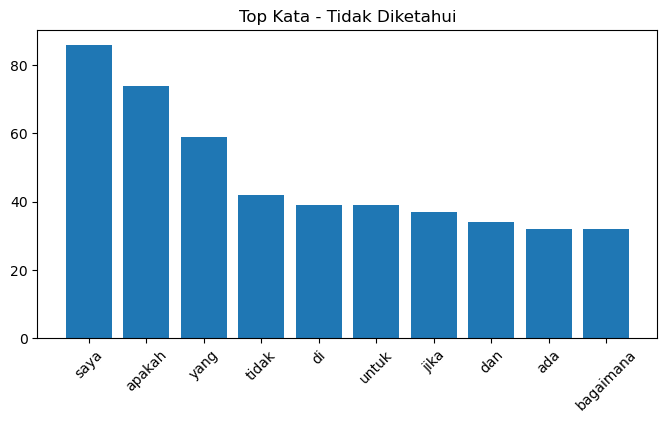

In [43]:
for kategori in df_feature["Kategori_Bersih"].unique():

    text = " ".join(
        df_feature[df_feature["Kategori_Bersih"] == kategori]["Pertanyaan"]
    )

    words = text.split()

    top_words = Counter(words).most_common(10)

    kata = [x[0] for x in top_words]
    jumlah = [x[1] for x in top_words]

    plt.figure(figsize=(8,4))
    plt.bar(kata, jumlah)

    plt.title(f"Top Kata - {kategori}")
    plt.xticks(rotation=45)
    plt.show()

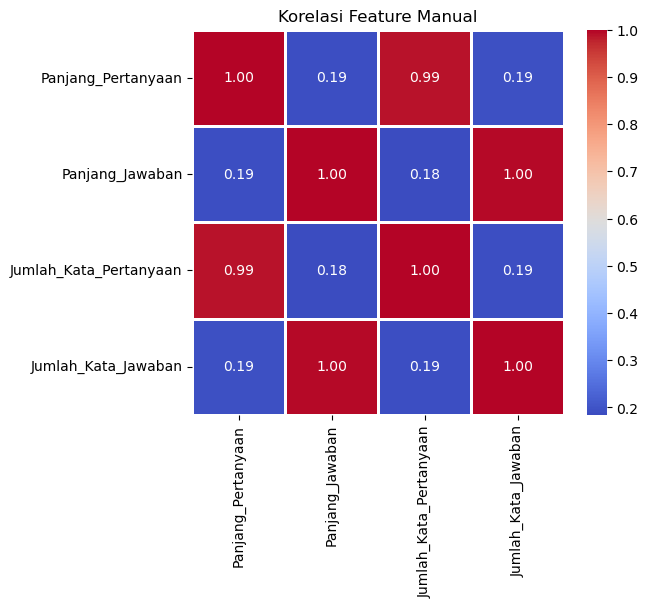

In [44]:

kolom = [
    "Panjang_Pertanyaan",
    "Panjang_Jawaban",
    "Jumlah_Kata_Pertanyaan",
    "Jumlah_Kata_Jawaban"
]

corr = df_feature[kolom].corr()

plt.figure(figsize=(6,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=1,
    fmt=".2f"
)

plt.title("Korelasi Feature Manual")
plt.show()

In [45]:
df_feature[
    ["Kategori_Bersih", "Pertanyaan", "Jumlah_Kata_Pertanyaan"]
].sort_values(
    by="Jumlah_Kata_Pertanyaan",
    ascending=False
).head(10)

,Kategori_Bersih,Pertanyaan,Jumlah_Kata_Pertanyaan
54,Full Stack Development,asslamualaikum saya ingin bertanya prihal sesi ilt tech1 saya dan sesi capst...,140
11,Data Sains,aku sudah dapet kelompok capstone aku sudah dapat status valid di kelompok c...,133
342,Full Stack Development,haloo kakk aku mau tanya terkait pengisian worksheet capstone kalau buktinya...,115
101,Full Stack Development,haloo kakk aku mau tanya terkait pengisian worksheet capstone kalau buktinya...,115
25,AI Engineer,halo ka sebelumnya saya waktu itu sudah hadir dan mengikuti live youtube ses...,108
364,AI Engineer,saya baru saja melihat jawaban dari pertanyaan saya di qna team meeting 1 te...,104
114,Tidak Diketahui,apa saja sertifikat yang perlu di perbarui pada catatan email hasil ma 1 \r\...,99
359,Data Sains,izin bertanya kak kemarin saya melakukan daily check in dengan memilih kelas...,97
323,AI Engineer,halo kak izin bertanya terkait capstone project\r\n\r\nsaya mendapatkan tim ...,96
5,Full Stack Development,malam kak mau nanya dari poin kedua al di tech stack ini itu maksudnya kita ...,91


**Insight** 
- Tidak ada jalur yang mendominasi secara signifikan (selisih maksimal hanya 7.1%), menandakan keaktifan bertanya yang seimbang antar jalur.
- Panjang pertanyaan cenderung pendek dan terpusat (distribusi right-skewed), artinya sebagian besar peserta bertanya singkat.
- Panjang jawaban lebih bervariasi — ada beberapa jawaban yang sangat panjang, mengindikasikan adanya jawaban template yang detail vs. jawaban singkat.
- Rata-rata panjang jawaban berbeda antar kategori jalur, menunjukkan kedalaman respons mentor tidak seragam.
- Kata paling sering muncul: ilt (89x), capstone (63x), masih (63x), sesi (62x), kelas (58x),dominasi kata administratif ini menandakan sebagian besar pertanyaan bersifat prosedural, bukan teknis — seputar jadwal ILT, mekanisme sesi, dan alur proyek Capstone.
- Full Stack Development sedikit berbeda — pertanyaannya lebih mengarah ke koordinasi teknis proyek, sementara Data Sains dan AI Engineer lebih banyak bertanya soal mekanisme program.
- WordCloud pertanyaan secara visual memperkuat temuan di atas — kata-kata besar yang muncul adalah istilah program (ilt, sesi, capstone), bukan istilah teknis seperti model, algoritma, atau framework.

### TF-IDF

In [46]:
df_feature["Pertanyaan"] = df_feature["Pertanyaan"].fillna("")
df_feature["Jawaban"] = df_feature["Jawaban"].fillna("")

In [47]:
def clean_text(text):
    text = str(text).lower()
    return re.sub(r"[^a-z0-9\s]", "", text)

df_feature["Jawaban"] = df_feature["Jawaban"].apply(clean_text)
df_feature["Pertanyaan"] = df_feature["Pertanyaan"].apply(clean_text)

In [48]:
tfidf = TfidfVectorizer(max_features=100, ngram_range=(1,2))

tfidf_matrix = tfidf.fit_transform(df_feature["Pertanyaan_Bersih"])


In [49]:
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)

tfidf_df.head()

,absent,abstrak,aju,aju banding,akhir,aku,anggota,apa,bagaimana,bagaimana cara,bagi,baik,banding,baru,beberapa,belum,buat,bukti,bulan,camp,capstone,cara,check,check in,coding,coding camp,daily,dapat,dashboard,data,deadline,dicoding,dosen,email,form,gimana,guna,hadir,halo,hari,hasil,ikut,ilt,in,isi,izin,izin tanya,jadi,kait,kak,kalau,kapan,kelas,kemarin,kerja,kirim,konversi,konversi sks,kumpul,laku,lalu,lapor,learning,lebih,lulus,ma,materi,mau,misal,model,modul,nilai,nya,padahal,poin,program,project,reschedule,salah,sama,satu,sebut,selesai,semua,sesi,sesi ilt,sks,ss,status,supervisor,tambah,tanggal,tanya,team,tentu,terima,tetap,tim,ubah,waktu
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.630091,0.0,0.0,0.320517,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0000,0.192882,0.000000,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.0,0.0,0.326319,0.371307,0.0,0.0,0.0,0.295838,0.0,0.0,0.362184,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.354439,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.309377,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.354439,0.0,0.0,0.0,0.0,0.0,0.0,0.284706,0.297363,0.0,0.0000,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.335794,0.0,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.314644,0.0,0.0,0.311974,0.0,0.0,0.0,0.339241,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.243677,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.522313,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.238330,0.248925,0.0,0.0000,0.000000,0.286977,0.286977,0.0,0.00000,0.0,0.293328,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.203985,0.0,0.0,0.0,0.0,0.562194,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0000,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.352651,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.54785,0.0,0.0,0.0,0.0,0.0,0.0,0.300464,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.3104,0.380075,0.000000,0.000000,0.0,0.33753,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.36123,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


In [ ]:
kolom_meta = ['Nama', 'Kategori', 'Kategori_Bersih',
              'Panjang_Pertanyaan', 'Panjang_Jawaban',
              'Jumlah_Kata_Pertanyaan', 'Jumlah_Kata_Jawaban',
              'Kategori_Label']

df_final = pd.concat([df_feature[kolom_meta].reset_index(drop=True), tfidf_df], axis=1)
df_final.to_csv("./data/dataset_tfidf.csv", index=False)

print("Shape:", df_final.shape)       

Shape: (355, 108)
Kolom 7-12: ['Kategori_Label', 'absent', 'abstrak', 'aju', 'aju banding']


### INDOBERT

In [51]:
model_name = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)
model.eval()  


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(50000, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [52]:
def get_embedding(text):
  
    text = str(text)

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )
    
    with torch.no_grad():
        outputs = model(**inputs)
    
   
    embedding = outputs.last_hidden_state[:, 0, :]
    
    return embedding.squeeze().numpy()

embeddings = df_feature["Pertanyaan"].apply(get_embedding)

In [53]:
emb_matrix = np.vstack(embeddings.values)

indo_df = pd.DataFrame(
    emb_matrix,
    columns=[f"indo_{i}" for i in range(emb_matrix.shape[1])]
)

indo_df.head()

,indo_0,indo_1,indo_2,indo_3,indo_4,indo_5,indo_6,indo_7,indo_8,indo_9,indo_10,indo_11,indo_12,indo_13,indo_14,indo_15,indo_16,indo_17,indo_18,indo_19,indo_20,indo_21,indo_22,indo_23,indo_24,indo_25,indo_26,indo_27,indo_28,indo_29,indo_30,indo_31,indo_32,indo_33,indo_34,indo_35,indo_36,indo_37,indo_38,indo_39,indo_40,indo_41,indo_42,indo_43,indo_44,indo_45,indo_46,indo_47,indo_48,indo_49,indo_50,indo_51,indo_52,indo_53,indo_54,indo_55,indo_56,indo_57,indo_58,indo_59,indo_60,indo_61,indo_62,indo_63,indo_64,indo_65,indo_66,indo_67,indo_68,indo_69,indo_70,indo_71,indo_72,indo_73,indo_74,indo_75,indo_76,indo_77,indo_78,indo_79,indo_80,indo_81,indo_82,indo_83,indo_84,indo_85,indo_86,indo_87,indo_88,indo_89,indo_90,indo_91,indo_92,indo_93,indo_94,indo_95,indo_96,indo_97,indo_98,indo_99,indo_100,indo_101,indo_102,indo_103,indo_104,indo_105,indo_106,indo_107,indo_108,indo_109,indo_110,indo_111,indo_112,indo_113,indo_114,indo_115,indo_116,indo_117,indo_118,indo_119,indo_120,indo_121,indo_122,indo_123,indo_124,indo_125,indo_126,indo_127,indo_128,indo_129,indo_130,indo_131,indo_132,indo_133,indo_134,indo_135,indo_136,indo_137,indo_138,indo_139,indo_140,indo_141,indo_142,indo_143,indo_144,indo_145,indo_146,indo_147,indo_148,indo_149,indo_150,indo_151,indo_152,indo_153,indo_154,indo_155,indo_156,indo_157,indo_158,indo_159,indo_160,indo_161,indo_162,indo_163,indo_164,indo_165,indo_166,indo_167,indo_168,indo_169,indo_170,indo_171,indo_172,indo_173,indo_174,indo_175,indo_176,indo_177,indo_178,indo_179,indo_180,indo_181,indo_182,indo_183,indo_184,indo_185,indo_186,indo_187,indo_188,indo_189,indo_190,indo_191,indo_192,indo_193,indo_194,indo_195,indo_196,indo_197,indo_198,indo_199,indo_200,indo_201,indo_202,indo_203,indo_204,indo_205,indo_206,indo_207,indo_208,indo_209,indo_210,indo_211,indo_212,indo_213,indo_214,indo_215,indo_216,indo_217,indo_218,indo_219,indo_220,indo_221,indo_222,indo_223,indo_224,indo_225,indo_226,indo_227,indo_228,indo_229,indo_230,indo_231,indo_232,indo_233,indo_234,indo_235,indo_236,indo_237,indo_238,indo_239,indo_240,indo_241,indo_242,indo_243,indo_244,indo_245,indo_246,indo_247,indo_248,indo_249,indo_250,indo_251,indo_252,indo_253,indo_254,indo_255,indo_256,indo_257,indo_258,indo_259,indo_260,indo_261,indo_262,indo_263,indo_264,indo_265,indo_266,indo_267,indo_268,indo_269,indo_270,indo_271,indo_272,indo_273,indo_274,indo_275,indo_276,indo_277,indo_278,indo_279,indo_280,indo_281,indo_282,indo_283,indo_284,indo_285,indo_286,indo_287,indo_288,indo_289,indo_290,indo_291,indo_292,indo_293,indo_294,indo_295,indo_296,indo_297,indo_298,indo_299,indo_300,indo_301,indo_302,indo_303,indo_304,indo_305,indo_306,indo_307,indo_308,indo_309,indo_310,indo_311,indo_312,indo_313,indo_314,indo_315,indo_316,indo_317,indo_318,indo_319,indo_320,indo_321,indo_322,indo_323,indo_324,indo_325,indo_326,indo_327,indo_328,indo_329,indo_330,indo_331,indo_332,indo_333,indo_334,indo_335,indo_336,indo_337,indo_338,indo_339,indo_340,indo_341,indo_342,indo_343,indo_344,indo_345,indo_346,indo_347,indo_348,indo_349,indo_350,indo_351,indo_352,indo_353,indo_354,indo_355,indo_356,indo_357,indo_358,indo_359,indo_360,indo_361,indo_362,indo_363,indo_364,indo_365,indo_366,indo_367,indo_368,indo_369,indo_370,indo_371,indo_372,indo_373,indo_374,indo_375,indo_376,indo_377,indo_378,indo_379,indo_380,indo_381,indo_382,indo_383,indo_384,indo_385,indo_386,indo_387,indo_388,indo_389,indo_390,indo_391,indo_392,indo_393,indo_394,indo_395,indo_396,indo_397,indo_398,indo_399,indo_400,indo_401,indo_402,indo_403,indo_404,indo_405,indo_406,indo_407,indo_408,indo_409,indo_410,indo_411,indo_412,indo_413,indo_414,indo_415,indo_416,indo_417,indo_418,indo_419,indo_420,indo_421,indo_422,indo_423,indo_424,indo_425,indo_426,indo_427,indo_428,indo_429,indo_430,indo_431,indo_432,indo_433,indo_434,indo_435,indo_436,indo_437,indo_438,indo_439,indo_440,indo_441,indo_442,indo_443,indo_444,indo_445,indo_446,indo_447,indo_448,indo_449,indo_450,indo_451,indo_452,indo_453,indo_454,indo_455,indo_

In [54]:
kolom_meta = ['Nama', 'Kategori', 'Kategori_Bersih',
              'Panjang_Pertanyaan', 'Panjang_Jawaban',
              'Jumlah_Kata_Pertanyaan', 'Jumlah_Kata_Jawaban',
              'Kategori_Label']

df_indo = pd.concat([df_feature[kolom_meta].reset_index(drop=True),
                           indo_df.reset_index(drop=True)], axis=1)

print("Shape:", df_indo.shape)  

Shape: (355, 776)


### pengecekam feature engineering(TF-IDF dan IndoBERT)

In [55]:
df_final.shape


(355, 108)

In [56]:
df_indo.shape


(355, 776)

In [57]:
df.shape

(355, 7)

In [58]:
df_final.shape
df_indo.shape

(355, 776)

In [59]:
tfidf_df.head()

,absent,abstrak,aju,aju banding,akhir,aku,anggota,apa,bagaimana,bagaimana cara,bagi,baik,banding,baru,beberapa,belum,buat,bukti,bulan,camp,capstone,cara,check,check in,coding,coding camp,daily,dapat,dashboard,data,deadline,dicoding,dosen,email,form,gimana,guna,hadir,halo,hari,hasil,ikut,ilt,in,isi,izin,izin tanya,jadi,kait,kak,kalau,kapan,kelas,kemarin,kerja,kirim,konversi,konversi sks,kumpul,laku,lalu,lapor,learning,lebih,lulus,ma,materi,mau,misal,model,modul,nilai,nya,padahal,poin,program,project,reschedule,salah,sama,satu,sebut,selesai,semua,sesi,sesi ilt,sks,ss,status,supervisor,tambah,tanggal,tanya,team,tentu,terima,tetap,tim,ubah,waktu
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.630091,0.0,0.0,0.320517,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0000,0.192882,0.000000,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.0,0.0,0.326319,0.371307,0.0,0.0,0.0,0.295838,0.0,0.0,0.362184,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.354439,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.309377,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.354439,0.0,0.0,0.0,0.0,0.0,0.0,0.284706,0.297363,0.0,0.0000,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.335794,0.0,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.314644,0.0,0.0,0.311974,0.0,0.0,0.0,0.339241,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.243677,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.522313,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.238330,0.248925,0.0,0.0000,0.000000,0.286977,0.286977,0.0,0.00000,0.0,0.293328,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.203985,0.0,0.0,0.0,0.0,0.562194,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0000,0.000000,0.000000,0.000000,0.0,0.00000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.00000,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.352651,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.54785,0.0,0.0,0.0,0.0,0.0,0.0,0.300464,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.0,0.3104,0.380075,0.000000,0.000000,0.0,0.33753,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.36123,0.0,0.0,0.0,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0


In [60]:
indo_df.head()

,indo_0,indo_1,indo_2,indo_3,indo_4,indo_5,indo_6,indo_7,indo_8,indo_9,indo_10,indo_11,indo_12,indo_13,indo_14,indo_15,indo_16,indo_17,indo_18,indo_19,indo_20,indo_21,indo_22,indo_23,indo_24,indo_25,indo_26,indo_27,indo_28,indo_29,indo_30,indo_31,indo_32,indo_33,indo_34,indo_35,indo_36,indo_37,indo_38,indo_39,indo_40,indo_41,indo_42,indo_43,indo_44,indo_45,indo_46,indo_47,indo_48,indo_49,indo_50,indo_51,indo_52,indo_53,indo_54,indo_55,indo_56,indo_57,indo_58,indo_59,indo_60,indo_61,indo_62,indo_63,indo_64,indo_65,indo_66,indo_67,indo_68,indo_69,indo_70,indo_71,indo_72,indo_73,indo_74,indo_75,indo_76,indo_77,indo_78,indo_79,indo_80,indo_81,indo_82,indo_83,indo_84,indo_85,indo_86,indo_87,indo_88,indo_89,indo_90,indo_91,indo_92,indo_93,indo_94,indo_95,indo_96,indo_97,indo_98,indo_99,indo_100,indo_101,indo_102,indo_103,indo_104,indo_105,indo_106,indo_107,indo_108,indo_109,indo_110,indo_111,indo_112,indo_113,indo_114,indo_115,indo_116,indo_117,indo_118,indo_119,indo_120,indo_121,indo_122,indo_123,indo_124,indo_125,indo_126,indo_127,indo_128,indo_129,indo_130,indo_131,indo_132,indo_133,indo_134,indo_135,indo_136,indo_137,indo_138,indo_139,indo_140,indo_141,indo_142,indo_143,indo_144,indo_145,indo_146,indo_147,indo_148,indo_149,indo_150,indo_151,indo_152,indo_153,indo_154,indo_155,indo_156,indo_157,indo_158,indo_159,indo_160,indo_161,indo_162,indo_163,indo_164,indo_165,indo_166,indo_167,indo_168,indo_169,indo_170,indo_171,indo_172,indo_173,indo_174,indo_175,indo_176,indo_177,indo_178,indo_179,indo_180,indo_181,indo_182,indo_183,indo_184,indo_185,indo_186,indo_187,indo_188,indo_189,indo_190,indo_191,indo_192,indo_193,indo_194,indo_195,indo_196,indo_197,indo_198,indo_199,indo_200,indo_201,indo_202,indo_203,indo_204,indo_205,indo_206,indo_207,indo_208,indo_209,indo_210,indo_211,indo_212,indo_213,indo_214,indo_215,indo_216,indo_217,indo_218,indo_219,indo_220,indo_221,indo_222,indo_223,indo_224,indo_225,indo_226,indo_227,indo_228,indo_229,indo_230,indo_231,indo_232,indo_233,indo_234,indo_235,indo_236,indo_237,indo_238,indo_239,indo_240,indo_241,indo_242,indo_243,indo_244,indo_245,indo_246,indo_247,indo_248,indo_249,indo_250,indo_251,indo_252,indo_253,indo_254,indo_255,indo_256,indo_257,indo_258,indo_259,indo_260,indo_261,indo_262,indo_263,indo_264,indo_265,indo_266,indo_267,indo_268,indo_269,indo_270,indo_271,indo_272,indo_273,indo_274,indo_275,indo_276,indo_277,indo_278,indo_279,indo_280,indo_281,indo_282,indo_283,indo_284,indo_285,indo_286,indo_287,indo_288,indo_289,indo_290,indo_291,indo_292,indo_293,indo_294,indo_295,indo_296,indo_297,indo_298,indo_299,indo_300,indo_301,indo_302,indo_303,indo_304,indo_305,indo_306,indo_307,indo_308,indo_309,indo_310,indo_311,indo_312,indo_313,indo_314,indo_315,indo_316,indo_317,indo_318,indo_319,indo_320,indo_321,indo_322,indo_323,indo_324,indo_325,indo_326,indo_327,indo_328,indo_329,indo_330,indo_331,indo_332,indo_333,indo_334,indo_335,indo_336,indo_337,indo_338,indo_339,indo_340,indo_341,indo_342,indo_343,indo_344,indo_345,indo_346,indo_347,indo_348,indo_349,indo_350,indo_351,indo_352,indo_353,indo_354,indo_355,indo_356,indo_357,indo_358,indo_359,indo_360,indo_361,indo_362,indo_363,indo_364,indo_365,indo_366,indo_367,indo_368,indo_369,indo_370,indo_371,indo_372,indo_373,indo_374,indo_375,indo_376,indo_377,indo_378,indo_379,indo_380,indo_381,indo_382,indo_383,indo_384,indo_385,indo_386,indo_387,indo_388,indo_389,indo_390,indo_391,indo_392,indo_393,indo_394,indo_395,indo_396,indo_397,indo_398,indo_399,indo_400,indo_401,indo_402,indo_403,indo_404,indo_405,indo_406,indo_407,indo_408,indo_409,indo_410,indo_411,indo_412,indo_413,indo_414,indo_415,indo_416,indo_417,indo_418,indo_419,indo_420,indo_421,indo_422,indo_423,indo_424,indo_425,indo_426,indo_427,indo_428,indo_429,indo_430,indo_431,indo_432,indo_433,indo_434,indo_435,indo_436,indo_437,indo_438,indo_439,indo_440,indo_441,indo_442,indo_443,indo_444,indo_445,indo_446,indo_447,indo_448,indo_449,indo_450,indo_451,indo_452,indo_453,indo_454,indo_455,indo_

In [61]:
tfidf_df.nunique().sum()

np.int64(2769)

In [62]:
indo_df.nunique().sum()

np.int64(271102)

In [63]:
df_final.iloc[0]
df_indo.iloc[0]

Nama                  Siddiq_Febri
Kategori                data sains
Kategori_Bersih         Data Sains
Panjang_Pertanyaan             220
Panjang_Jawaban                 80
                          ...     
indo_763                  1.031079
indo_764                 -0.294737
indo_765                 -0.608496
indo_766                   0.07629
indo_767                 -0.186644
Name: 0, Length: 776, dtype: object

In [64]:
df_indo.to_csv("./data/dataset_indobert.csv", index=False)

## menjawab pertanyaan bisnis


### 1.1.Kategori jalur mana (ai engineer, data sains, full stack development) yang memiliki volume pertanyaan terbanyak dalam dataset, dan berapa persentase dominasinya?


In [65]:
df_final.columns

Index(['Nama', 'Kategori', 'Kategori_Bersih', 'Panjang_Pertanyaan',
       'Panjang_Jawaban', 'Jumlah_Kata_Pertanyaan', 'Jumlah_Kata_Jawaban',
       'Kategori_Label', 'absent', 'abstrak',
       ...
       'tambah', 'tanggal', 'tanya', 'team', 'tentu', 'terima', 'tetap', 'tim',
       'ubah', 'waktu'],
      dtype='object', length=108)


PERTANYAAN BISNIS #1: Distribusi Volume Pertanyaan per Jalur

Ringkasan Distribusi:
                        Jumlah Pertanyaan  Persentase (%)
Kategori_Bersih                                          
Data Sains                             93           36.61
Full Stack Development                 86           33.86
AI Engineer                            75           29.53


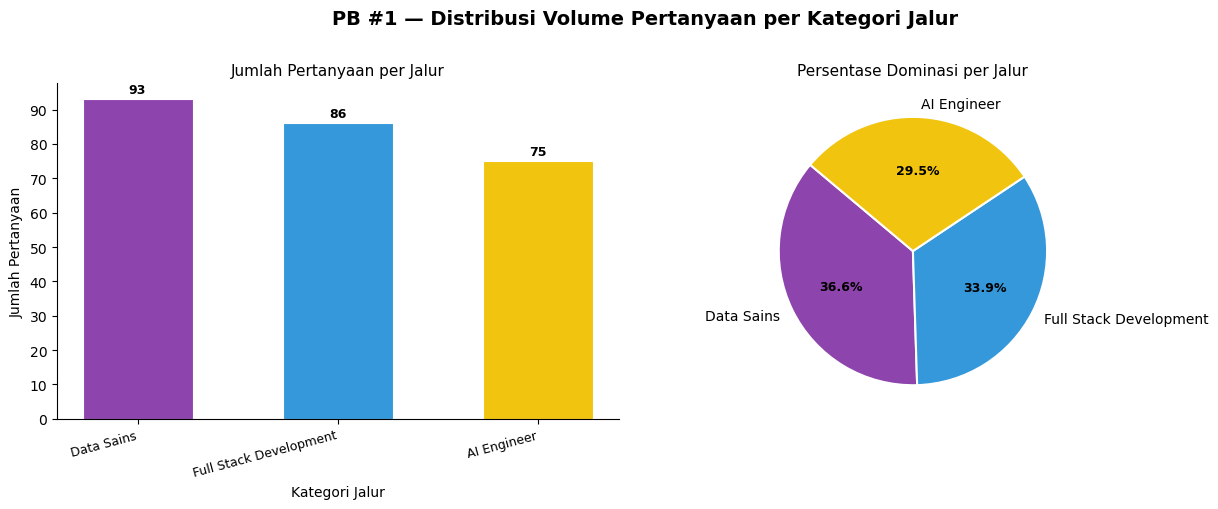


[INSIGHT PB #1]
Kategori dengan pertanyaan terbanyak : 'Data Sains' (36.6%)
Total pertanyaan teridentifikasi     : 254 dari 365 data
Data tidak teridentifikasi (Path NaN): 111 baris (dihapus saat cleaning)


In [66]:
print("\n" + "="*60)
print("PERTANYAAN BISNIS #1: Distribusi Volume Pertanyaan per Jalur")
print("="*60)

# Ambil hanya kategori valid
df_pb1 = df[df['Kategori_Bersih'] != 'Tidak Diketahui']
#  distribusi
distribusi = df_pb1['Kategori_Bersih'].value_counts()
distribusi_persen = df_pb1['Kategori_Bersih'].value_counts(normalize=True) * 100

ringkasan_pb1 = pd.DataFrame({
    'Jumlah Pertanyaan': distribusi,
    'Persentase (%)': distribusi_persen.round(2)
})
print("\nRingkasan Distribusi:")
print(ringkasan_pb1.to_string())

# Visualisasi
WARNA = ['#8E44AD', '#3498DB', '#F1C40F']
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    'PB #1 — Distribusi Volume Pertanyaan per Kategori Jalur',
    fontsize=14, fontweight='bold', y=1.01
)

# Bar Chart
kategori_label = distribusi.index.tolist()
jumlah        = distribusi.values.tolist()
bars = axes[0].bar(kategori_label, jumlah, color=WARNA[:len(kategori_label)],
                   edgecolor='white', linewidth=0.8, width=0.55)
axes[0].set_title('Jumlah Pertanyaan per Jalur', fontsize=11)
axes[0].set_xlabel('Kategori Jalur', fontsize=10)
axes[0].set_ylabel('Jumlah Pertanyaan', fontsize=10)
axes[0].set_xticks(range(len(kategori_label)))
axes[0].set_xticklabels(kategori_label, rotation=15, ha='right', fontsize=9)
axes[0].yaxis.set_major_locator(mticker.MaxNLocator(integer=True))
axes[0].spines[['top', 'right']].set_visible(False)
# Tambahkan angka di atas bar
for bar, val in zip(bars, jumlah):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 str(val), ha='center', va='bottom', fontsize=9, fontweight='bold')

# Pie Chart
persen = distribusi_persen.values.tolist()
wedges, texts, autotexts = axes[1].pie(
    persen,
    labels=kategori_label,
    autopct='%1.1f%%',
    colors=WARNA[:len(kategori_label)],
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')
axes[1].set_title('Persentase Dominasi per Jalur', fontsize=11)

plt.tight_layout()
#plt.savefig('pb1_distribusi_kategori.png', dpi=150, bbox_inches='tight')
plt.show()

# Insight otomatis
df_asli = pd.read_csv("./data/Dataset_capstone_Project.csv")
total_asli = len(df_asli)

jalur_terbanyak  = distribusi.idxmax()
jalur_persen     = distribusi_persen.max()
total_teridentifikasi = distribusi.sum()
total_tidak_diketahui = total_asli - total_teridentifikasi

print(f"\n[INSIGHT PB #1]")
print(f"Kategori dengan pertanyaan terbanyak : '{jalur_terbanyak}' ({jalur_persen:.1f}%)")
print(f"Total pertanyaan teridentifikasi     : {total_teridentifikasi} dari {total_asli} data")
print(f"Data tidak teridentifikasi (Path NaN): {total_tidak_diketahui} baris (dihapus saat cleaning)")

### 2.Apa 10 kata kunci atau topik yang paling sering muncul dalam pertanyaan peserta secara keseluruhan, dan apakah topik tersebut berbeda antar kategori jalur?



PERTANYAAN BISNIS #2: Top-10 Kata Kunci per Kategori Jalur

Top-10 Kata Kunci (Semua Jalur):
    Kata  Frekuensi
     ilt         89
capstone         63
   masih         63
    sesi         62
   kelas         58
    data         52
   email         50
   harus         49
tersebut         48
    hari         46


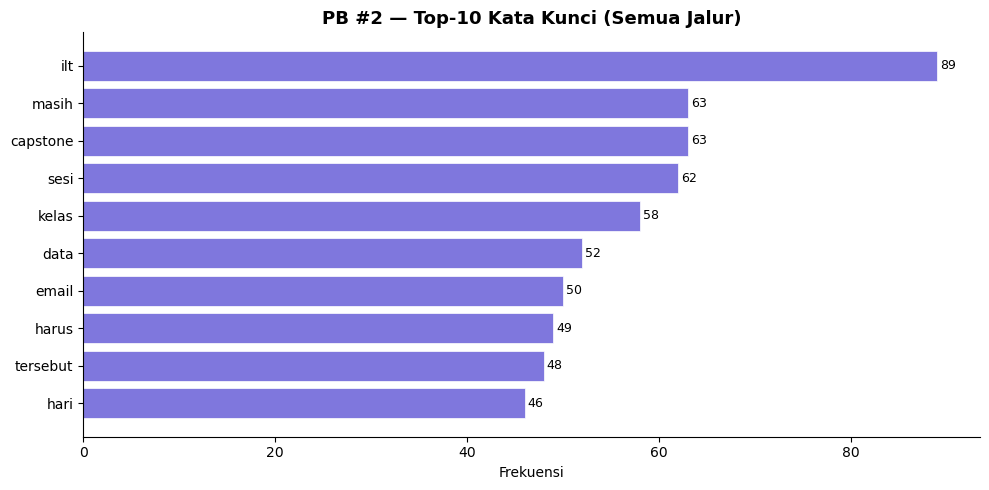

In [72]:
print("\n" + "="*60)
print("PERTANYAAN BISNIS #2: Top-10 Kata Kunci per Kategori Jalur")
print("="*60)

STOPWORD = {
    'yang', 'dan', 'di', 'ke', 'dari', 'untuk', 'dengan', 'ini', 'itu',
    'saya', 'kak', 'ya', 'ada', 'tidak', 'bisa', 'sudah', 'akan', 'jika',
    'apakah', 'atau', 'pada', 'mau', 'nanya', 'tanya', 'bagaimana', 'gimana',
    'boleh', 'buat', 'izin', 'bertanya', 'halo', 'permisi', 'mohon', 'minta',
    'kami', 'kita', 'jadi', 'kalo', 'kalau', 'dalam', 'setelah', 'kapan',
    'adalah', 'apa', 'karena', 'juga', 'agar', 'lebih', 'lagi', 'saat',
    'nya', 'sih', 'kan', 'dong', 'nih', 'lah', 'banget', 'juga', 'sudah',
    'belum', 'bisa', 'agar', 'seperti', 'kalau', 'apakah', 'namun', 'tapi'
}

def ekstrak_kata(teks_series):
    semua_kata = []
    for teks in teks_series.dropna():
        teks = teks.lower()
        teks = re.sub(r'[^a-z\s]', ' ', teks)
        kata_list = [k for k in teks.split() if len(k) > 2 and k not in STOPWORD]
        semua_kata.extend(kata_list)
    return semua_kata
#  Top-10 kata GLOBAL 
kata_global = ekstrak_kata(df_feature['Pertanyaan'])
top10_global = Counter(kata_global).most_common(10)
df_global = pd.DataFrame(top10_global, columns=['Kata', 'Frekuensi'])
print("\nTop-10 Kata Kunci (Semua Jalur):")
print(df_global.to_string(index=False))

#  Top-10 kata per KATEGORI 

kategori_unik = [k for k in df_feature['Kategori_Bersih'].unique() if k != 'tidak_diketahui']
top10_per_kategori = {}
for kat in kategori_unik:
    subset = df_feature[df_feature['Kategori_Bersih'] == kat]['Pertanyaan']
    kata_kat = ekstrak_kata(subset)
    top10_per_kategori[kat] = Counter(kata_kat).most_common(10)

# Visualisasi Global
fig, ax = plt.subplots(figsize=(10, 5))
df_global_sorted = df_global.sort_values('Frekuensi', ascending=True)
bars = ax.barh(df_global_sorted['Kata'], df_global_sorted['Frekuensi'],
               color='#7F77DD', edgecolor='white', linewidth=0.5)
ax.set_title('PB #2 — Top-10 Kata Kunci (Semua Jalur)', fontsize=13, fontweight='bold')
ax.set_xlabel('Frekuensi', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            str(int(bar.get_width())), va='center', fontsize=9)
plt.tight_layout()
#plt.savefig('pb2_global.png', dpi=150, bbox_inches='tight')
plt.show()

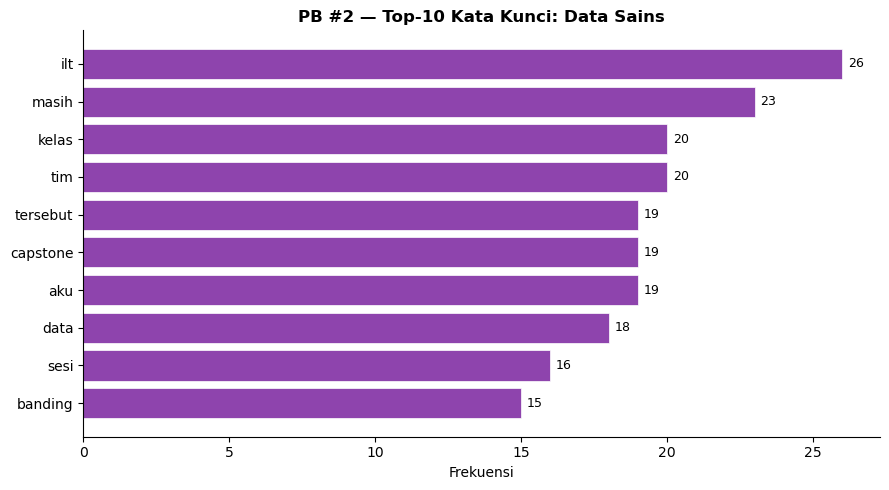

In [73]:
kat, warna = 'Data Sains', '#8E44AD'
df_kat = pd.DataFrame(top10_per_kategori[kat], columns=['Kata', 'Frekuensi'])
df_kat_sorted = df_kat.sort_values('Frekuensi', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(df_kat_sorted['Kata'], df_kat_sorted['Frekuensi'],
               color=warna, edgecolor='white', linewidth=0.5)
ax.set_title(f'PB #2 — Top-10 Kata Kunci: {kat}', fontsize=12, fontweight='bold')
ax.set_xlabel('Frekuensi', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=10)
for bar in bars:
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            str(int(bar.get_width())), va='center', fontsize=9)
plt.tight_layout()
#plt.savefig('pb2_data_sains.png', dpi=150, bbox_inches='tight')
plt.show()

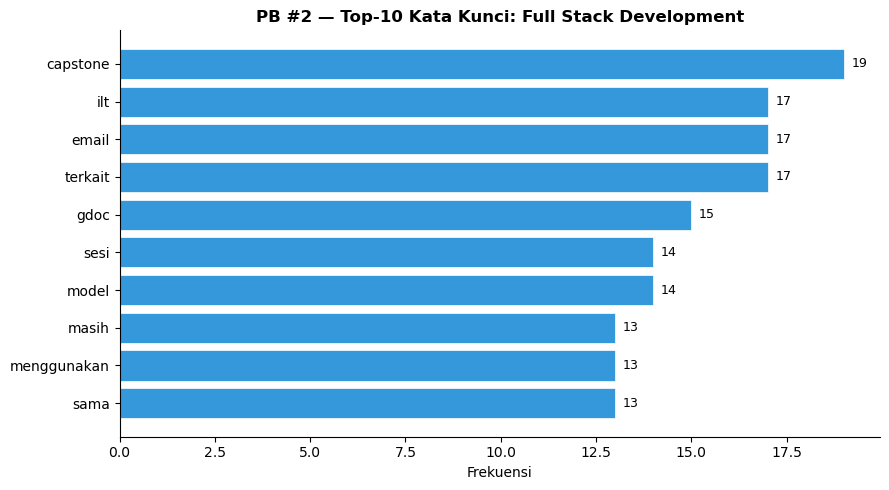

In [74]:
kat, warna = 'Full Stack Development', '#3498DB'
df_kat = pd.DataFrame(top10_per_kategori[kat], columns=['Kata', 'Frekuensi'])
df_kat_sorted = df_kat.sort_values('Frekuensi', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(df_kat_sorted['Kata'], df_kat_sorted['Frekuensi'],
               color=warna, edgecolor='white', linewidth=0.5)
ax.set_title(f'PB #2 — Top-10 Kata Kunci: {kat}', fontsize=12, fontweight='bold')
ax.set_xlabel('Frekuensi', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=10)
for bar in bars:
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            str(int(bar.get_width())), va='center', fontsize=9)
plt.tight_layout()
#plt.savefig('pb2_fullstack.png', dpi=150, bbox_inches='tight')
plt.show()

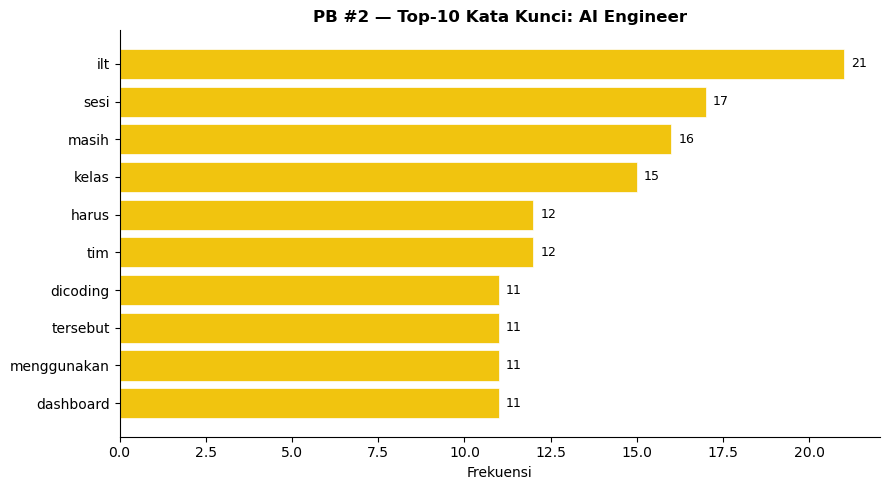

In [75]:
kat, warna = 'AI Engineer', '#F1C40F'
df_kat = pd.DataFrame(top10_per_kategori[kat], columns=['Kata', 'Frekuensi'])
df_kat_sorted = df_kat.sort_values('Frekuensi', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(df_kat_sorted['Kata'], df_kat_sorted['Frekuensi'],
               color=warna, edgecolor='white', linewidth=0.5)
ax.set_title(f'PB #2 — Top-10 Kata Kunci: {kat}', fontsize=12, fontweight='bold')
ax.set_xlabel('Frekuensi', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(axis='y', labelsize=10)
for bar in bars:
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height() / 2,
            str(int(bar.get_width())), va='center', fontsize=9)
plt.tight_layout()
#plt.savefig('pb2_ai_engineer.png', dpi=150, bbox_inches='tight')
plt.show()

## insight Pertanyaan Bisnis
 
 **Catatan:** 
- Dataset tidak memiliki kolom timestamp atau tanggal,sehingga analisis berbasis waktu tidak dapat dilakukan secara spesifik.
- tetapi Seluruh kesimpulan berikut berlaku dalam lingkup satu periode program Coding Camp sesuai data yang tersedia.
- Pengumpulan data dilakukan tanggal 9 Februari 2026, sampai 17 April 2026.

### PB #1 — Distribusi Volume Pertanyaan per Kategori Jalur

Dari total 365 data pertanyaan dalam dataset, sebanyak **254 pertanyaan (69.6%)** 
berhasil diidentifikasi kategori jalurnya, sedangkan **111 data (30.4%)** tidak 
dapat diidentifikasi karena kolom Path kosong (NaN) dan dihapus pada tahap cleaning.

Dari 254 data yang teridentifikasi, distribusi per jalur adalah sebagai berikut:

| Kategori Jalur        | Jumlah | Persentase |
|-----------------------|--------|------------|
| Data Sains            | 93     | 36.6%      |
| Full Stack Development| 86     | 33.9%      |
| AI Engineer           | 75     | 29.5%      |

**Kesimpulan:** Jalur **Data Sains** memiliki volume pertanyaan tertinggi (36.6%), 
namun perbedaan antar ketiga jalur relatif kecil (selisih maksimal 7.1%). 
Hal ini menunjukkan tingkat keaktifan bertanya yang **cukup merata** antar jalur, 
sehingga tidak ada satu jalur pun yang secara signifikan lebih membutuhkan 
perhatian mentor dibanding jalur lainnya. Program dapat mempertimbangkan 
alokasi sumber daya mentor yang proporsional untuk ketiga jalur.


### PB #2 — Top-10 Kata Kunci dalam Pertanyaan Peserta

Secara global, kata yang paling dominan muncul adalah **"ilt"** (89x), 
**"capstone"** (63x), **"masih"** (63x), **"sesi"** (62x), dan **"kelas"** (58x). 
Dominasi kata "ilt" dan "sesi" mengindikasikan bahwa sebagian besar pertanyaan 
berkaitan dengan **kegiatan kelas dan sesi ILT (Instructor-Led Training)**, 
bukan pertanyaan teknis spesifik per jalur.

Perbandingan kata kunci #1 per kategori:

| Kategori Jalur        | Kata #1   | Frekuensi | Interpretasi                          |
|-----------------------|-----------|-----------|---------------------------------------|
| Data Sains            | ilt       | 26x       | Pertanyaan seputar sesi kelas ILT     |
| Full Stack Development| capstone  | 19x       | Pertanyaan seputar proyek Capstone    |
| AI Engineer           | ilt       | 21x       | Pertanyaan seputar sesi kelas ILT     |

**Perbedaan antar jalur:**
- **Data Sains & AI Engineer** → didominasi kata administratif seperti *ilt*, 
  *sesi*, *kelas*, *masih*, menunjukkan banyak pertanyaan terkait 
  jadwal dan mekanisme program.
- **Full Stack Development** → kata unik seperti *gdoc*, *terkait*, *email*, 
  *model* menunjukkan pertanyaan lebih banyak seputar 
  dokumen teknis dan koordinasi proyek.

**Kesimpulan:** Sebagian besar pertanyaan peserta dari ketiga jalur bersifat 
**administratif dan prosedural** (ILT, sesi, email, capstone), bukan pertanyaan 
teknis mendalam. Ini menjadi sinyal bahwa **Playbook Capstone dan FAQ resmi** 
perlu diperkuat dengan informasi prosedural yang lebih lengkap agar pertanyaan 
berulang dapat diminimalkan — yang sejalan langsung dengan tujuan pengembangan 
produk *Coding Camp Copilot* pada proyek ini,serta 